# Activity 1: Install and Import Required Libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Activity 2: Visualize Activation Functions

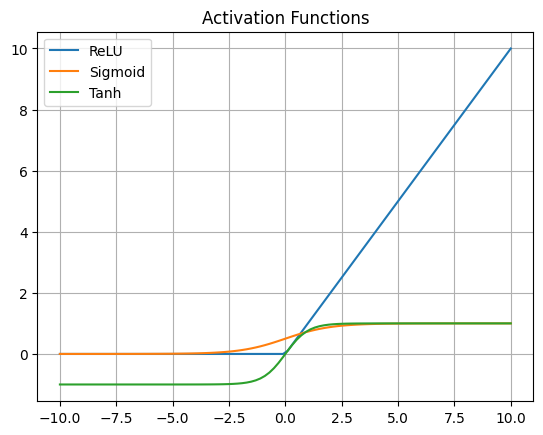

In [3]:
x = np.linspace(-10, 10, 100)
relu = np.maximum(0, x)
sigmoid = 1 / (1 + np.exp(-x))
tanh = np.tanh(x)

plt.plot(x, relu, label='ReLU')
plt.plot(x, sigmoid, label='Sigmoid')
plt.plot(x, tanh, label='Tanh')
plt.legend()
plt.title('Activation Functions')
plt.grid(True)
plt.show()


# Activity 3: Build a Simple Neural Network

In [4]:
model = keras.Sequential([
    layers.Dense(16, activation='relu', input_shape=(2,)),
    layers.Dense(1, activation='sigmoid')
])
model.summary()


c:\Users\mhamz\anaconda3\envs\tensorflow\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 65 (260.00 B)

 Trainable params: 65 (260.00 B)

 Non-trainable params: 0 (0.00 B)

# Activity 4: Compile the Network with SGD Optimizer

In [5]:
model.compile(optimizer='sgd',
              loss='binary_crossentropy',
              metrics=['accuracy'])


# Activity 5: Create a Realistic Dataset (Job Prediction)

In [6]:
# Features: [correct_interview_answers, years_experience]
X = np.array([[5,1], [7,1], [8,2], [6,3], [9,4], [2,1], [1,0], [3,2], [10,5], [4,3]])
# Labels: 1 = Got job, 0 = Didn't get job
y = np.array([1,1,1,1,1,0,0,0,1,0])


# Activity 6: Train the Model

In [7]:
model.fit(X, y, epochs=100, verbose=0)

# Activity 7: Evaluate the Model

In [8]:
loss, accuracy = model.evaluate(X, y)
print("Loss:", loss, "Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step - accuracy: 0.7000 - loss: 0.4483
Loss: 0.44827479124069214 Accuracy: 0.699999988079071


# Activity 8: Make a Prediction

In [9]:
test_data = np.array([[6, 2]])  # 6 correct answers, 2 years experience
prediction = model.predict(test_data)
print("Prediction (probability of getting job):", prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step
Prediction (probability of getting job): [[0.7973759]]


# Activity 9: Visualize Decision Boundary (optional for 2D data)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


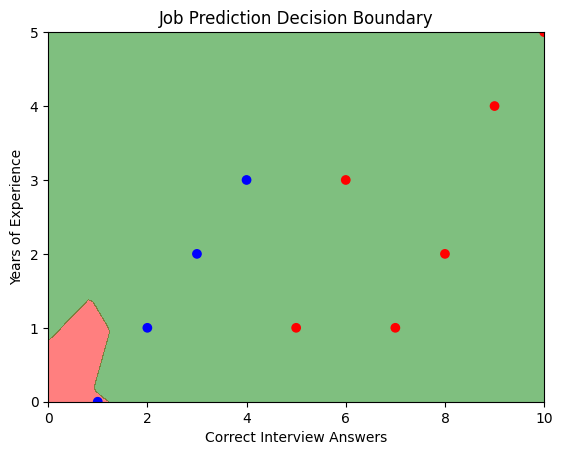

In [ ]:

x1 = np.linspace(0, 10, 100)
x2 = np.linspace(0, 5, 100)
xx, yy = np.meshgrid(x1, x2)
zz = model.predict(np.c_[xx.ravel(), yy.ravel()])
zz = zz.reshape(xx.shape)

plt.contourf(xx, yy, zz, levels=[0, 0.5, 1], alpha=0.5, colors=['red','green'])
plt.scatter(X[:,0], X[:,1], c=y, cmap='bwr')
plt.xlabel("Correct Interview Answers")
plt.ylabel("Years of Experience")
plt.title("Job Prediction Decision Boundary")
plt.show()


# Activity 10: Manually Observe Gradient Descent Progress

In [11]:
# Using callbacks to observe loss changes
class PrintLossCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {logs['loss']:.4f}")

model.fit(X, y, epochs=100, callbacks=[PrintLossCallback()], verbose=0)


Epoch 0, Loss: 0.4483
Epoch 10, Loss: 0.4395
Epoch 20, Loss: 0.4309
Epoch 30, Loss: 0.4225
Epoch 40, Loss: 0.4144
Epoch 50, Loss: 0.4065
Epoch 60, Loss: 0.3988
Epoch 70, Loss: 0.3913
Epoch 80, Loss: 0.3839
Epoch 90, Loss: 0.3768
